In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [16]:
data = pd.read_csv(r"C:\Users\insan\OneDrive\Desktop\Housing.csv")
print(data.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [17]:
print(data.shape)
print(data.info())

(545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [21]:
for col in data.columns:
    if data[col].dtype == "object":
        data[col] = data[col].fillna("Missing")
    else:
        data[col] = data[col].fillna(data[col].median())

In [22]:
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == "object":
        data[col] = le.fit_transform(data[col])

In [23]:
print(data.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [24]:
X = data.drop("price", axis=1)
y = data["price"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [28]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [30]:
predictions = model.predict(X_test)

In [31]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 1025289.6821100918
R2 Score: 0.6115321143409216


In [32]:
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

print(result.head(10))

   Actual Price  Predicted Price
0       4060000       5211325.00
1       6650000       7425040.00
2       3710000       3762158.75
3       6440000       4517170.00
4       2800000       3733800.00
5       4900000       3488380.00
6       5250000       5106360.00
7       4543000       5199390.00
8       2450000       2561930.00
9       3353000       2878067.50


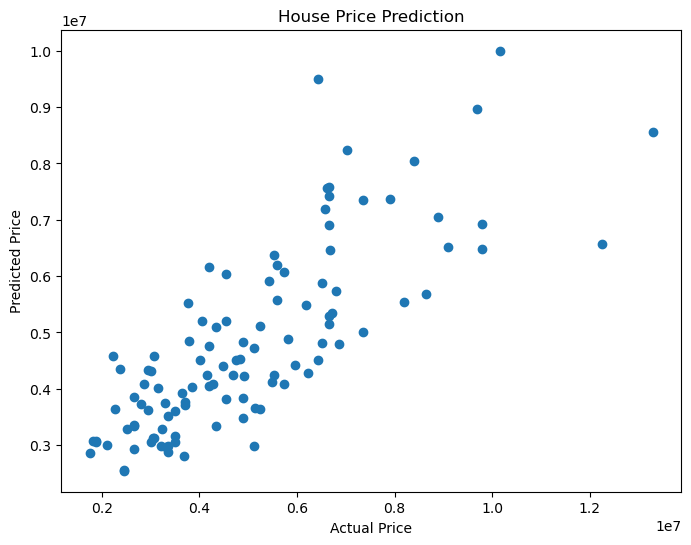

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("House Price Prediction")
plt.show()

In [34]:
sample_house = [[
    5000,  # area
    3,     # bedrooms
    2,     # bathrooms
    2,     # stories
    1,     # mainroad
    0,     # guestroom
    1,     # basement
    0,     # hotwaterheating
    1,     # airconditioning
    2,     # parking
    1,     # prefarea
    2      # furnishingstatus
]]

predicted_price = model.predict(sample_house)
print("Predicted House Price:", predicted_price[0])

Predicted House Price: 6935880.0


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
